#### Data Story - is cost a function of time and size.

Here's a way to ask this question: 

Within the same time frame and geog, do a commercial and residential customer pay the same for the same size install.


In [1]:
# %load ../pycode/setup.py
# set up
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

%matplotlib inline

def ecdf(data):
    '''Compute ECDF for a one-dimensional array of measurements.'''
    n = len(data)
    x = np.sort(data)
    y = np.arange(1, n + 1) / n
    return x, y

def min015099max(series):
    ''' return list of [ min, 1%, median, 99%, max ] series values '''
    vals = list(np.percentile(series, [1.0, 50.0, 99.0]))
    vals.insert(-1, series.max())
    vals.insert(0, series.min())
    return vals

# ss = np.arange(1, 101)
# min_1_50_99_max(ss)             

def mid98(series):
    '''  return middle 98% of series '''
    bounds = series.quantile([0.01, 0.99])
    return(series[(series > bounds.values[0]) & (series < bounds.values[1])])

# ss = np.arange(1, 101)
# min_1_50_99_max(ss)


In [7]:
# revisit with TTS data
# dfLive = pd.read_csv('../local/data/20180105', index_col='date_installed', parse_dates=True)
dftts = pd.read_csv('../local/data/LBNL_openpv_tts_data/ttsclean20180119.csv', 
                     index_col='row_id', 
                     parse_dates=['install_date'],
                     dtype={'zipcode' : np.object})

In [8]:
dftts.describe()

,file_row,size_kw,price,cost_per_watt
count,7.865800e+05,7.865800e+05,7.865800e+05,7.865800e+05
mean,1.376065e+07,1.103484e+01,3.538467e+05,7.111638e+10
std,4.685861e+06,6.927191e+01,2.504812e+08,6.307265e+13
min,1.000000e+07,9.768000e-16,1.000000e-02,2.184503e-09
25%,1.029881e+07,4.080000e+00,1.942865e+04,3.993870e+00
50%,1.055057e+07,5.870000e+00,2.795520e+04,4.920000e+00
75%,2.011833e+07,8.250000e+00,3.989269e+04,5.817021e+00
max,2.039491e+07,7.569000e+03,2.220000e+11,5.593872e+16


In [10]:
dftts.describe(include=[np.object])

,data_provider,sysid_dp,sysid_tts,cust_type,zipcode,city,county,state
count,786580,772671,786580,786580,786580,782628,602759,786580
unique,52,765891,786580,7,9730,9506,477,19
top,California Public Utilities Commission (Curren...,21,CA-NEM-279569,RES,95762.0,SAN DIEGO,SAN DIEGO,CA
freq,229489,10,1,755954,2655,22736,69828,466987


In [11]:
dftts.describe(include=[np.bool])

,appraised_value,new_const,tracking,ground_mounted,battery,third-party,uinverter,dc_optimizer
count,786580,786580,786580,786580,786580,786580,786580,786580
unique,2,2,2,2,2,2,2,2
top,False,False,False,False,False,False,False,False
freq,556275,756513,783355,773882,786418,434114,624869,662043


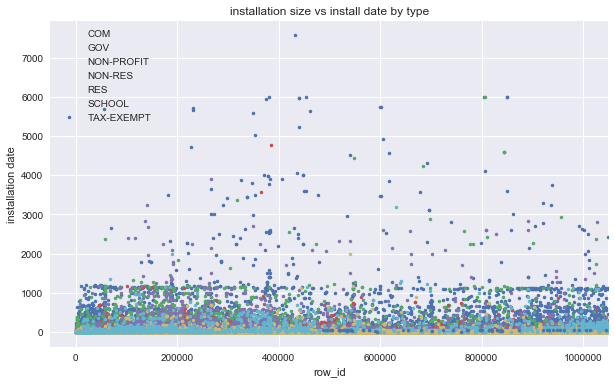

In [15]:
byType = dftts.groupby('cust_type')
plt.rc('figure', figsize=(10, 6))
byType.size_kw.plot(marker='.', linestyle='none', legend=True);
plt.ylabel('size in kilowatts')
plt.ylabel('installation date')
plt.xlim(-50000, 1050000)
plt.title('installation size vs install date by type');

In [19]:
# look at res size > 100kw
res_install = dftts['cust_type'] == 'RES'

In [20]:
res_huge = dftts.loc[res_install & (dftts.size_kw > 1000)]
res_huge.describe()
res_huge

,file_row,data_provider,sysid_dp,sysid_tts,install_date,size_kw,price,appraised_value,cust_type,new_const,...,ground_mounted,battery,zipcode,city,county,state,third-party,uinverter,dc_optimizer,cost_per_watt
row_id,,,,,,,,,,,,,,,,,,,,,
444065,10465392,California Public Utilities Commission (Curren...,SCE-INT-500520614 & SCE-CSI-58377,CA-NEM-370818,2014-06-10,1129.905,3110743.00,False,RES,False,...,False,False,92241.0,DESERT HOT SPRINGS,Riverside,CA,False,False,False,2.753101
539919,20150172,Massachusetts Department of Energy Resources,NFG-SR25630-36344,MA_DOER_CEC_44882,2014-12-18,1989.520,3720864.00,False,RES,False,...,False,False,2720.0,Fall River,NaN,MA,False,False,False,1.870232
546615,20146944,Massachusetts Department of Energy Resources,NFG-SR25630-28508,MA_DOER_CEC_41564,2014-12-30,1178.100,3100000.00,False,RES,False,...,False,False,1740.0,Bolton,NaN,MA,False,False,False,2.631356
1050937,10574497,California Public Utilities Commission (Curren...,SCE-INT-SCE-69806 & SCE-MASH-00194,CA-NEM-479958,2016-10-27,1058.760,57364.41,False,RES,False,...,False,False,92840.0,GARDEN GROVE,Orange,CA,True,False,False,0.054181


In [32]:
# residential installs
dfRes = dftts[dftts.cust_type == 'RES']

In [33]:
# median res install is 5.75kw
dfRes.size_kw.describe()

count    7.559540e+05
mean     6.468792e+00
std      7.400556e+00
min      9.768000e-16
25%      4.022857e+00
50%      5.750000e+00
75%      7.965000e+00
max      1.989520e+03
Name: size_kw, dtype: float64

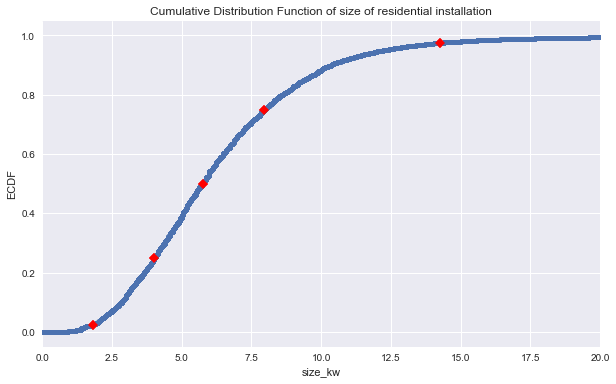

In [23]:
resSizes = dftts[dftts.cust_type == 'RES'].size_kw
xx, yy = ecdf(resSizes)
### shows a nice graph of size CDF with percentiles highlighted
percentiles = np.array([2.5, 25, 50, 75, 97.5])
ptiles = np.percentile(xx, percentiles)
plt.plot(ptiles, percentiles/100, marker='D', color='red', linestyle='none')
plt.xlim((0, 20))
plt.plot(xx, yy, marker='.', linestyle='none')
plt.xlabel('size_kw')
plt.ylabel('ECDF')
plt.title('Cumulative Distribution Function of size of residential installation');
plt.plot(ptiles, percentiles/100, marker='D', color='red', linestyle='none')


In [34]:
dfCom = dftts[dftts.cust_type == 'COM']

In [35]:
# median res install is 25.5kw, almost 5 times as big
dfCom.size_kw.describe()

count    15594.000000
mean       134.425892
std        379.520600
min          0.060000
25%         10.050000
50%         25.534321
75%         83.915582
max       7569.000000
Name: size_kw, dtype: float64

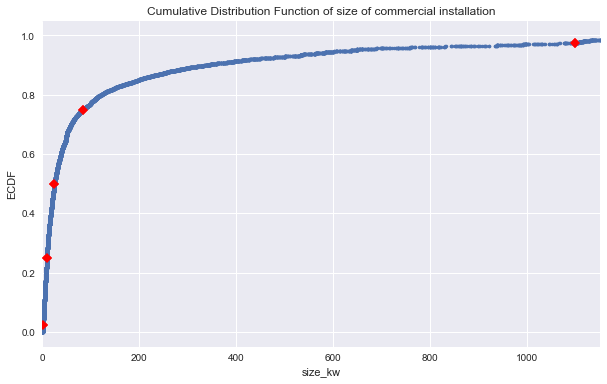

In [29]:
comSizes = dftts[dftts.cust_type == 'COM'].size_kw
xx, yy = ecdf(comSizes)
### shows a nice graph of size CDF with percentiles highlighted
percentiles = np.array([2.5, 25, 50, 75, 97.5])
ptiles = np.percentile(xx, percentiles)
plt.plot(ptiles, percentiles/100, marker='D', color='red', linestyle='none')
plt.xlim((0, 1150))
plt.plot(xx, yy, marker='.', linestyle='none')
plt.xlabel('size_kw')
plt.ylabel('ECDF')
plt.title('Cumulative Distribution Function of size of commercial installation');
plt.plot(ptiles, percentiles/100, marker='D', color='red', linestyle='none');
